# 04 Transformer Models and Explanation Assistant
This notebook reviews saved multilingual transformer metrics and explanation samples without loading checkpoints or training models.

## Why Transformers Were Added
Pretrained multilingual encoders provide contextual representations and a useful comparison with TF-IDF and randomly initialized neural models.

## mBERT
mBERT is a multilingual BERT encoder evaluated as a three-class sequence classifier.

## XLM-RoBERTa
XLM-RoBERTa uses multilingual masked-language-model pretraining and was the stronger of the two saved transformer runs.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'outputs' / 'results'
ERRORS = ROOT / 'outputs' / 'error_analysis'

transformers = pd.read_csv(RESULTS / 'transformer_leaderboard.csv', encoding='utf-8')
transformer_metrics = json.loads((RESULTS / 'transformer_metrics.json').read_text(encoding='utf-8'))
comparison = pd.read_csv(RESULTS / 'model_comparison_leaderboard.csv', encoding='utf-8')
explanation_samples = json.loads((ERRORS / 'explanation_samples.json').read_text(encoding='utf-8'))

## Training Configuration
The saved transformer experiments used maximum sequence length 96, class-weight smoothing, and multilingual pretrained checkpoints.

## Limited-Compute Setup
Both transformers were trained on a stratified 50,000-example training subset for one epoch. Their scores must be interpreted as resource-constrained experiments, not fully optimized transformer results.

## Transformer Leaderboard
XLM-RoBERTa is the best saved transformer on both accuracy and Macro-F1.

In [2]:
transformer_test = transformers.query("split == 'test'").sort_values('macro_f1', ascending=False)
transformer_test[['model_name', 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1']].style.format('{:.4f}', subset=['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_f1'])

,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
1,xlm_roberta,0.8528,0.4501,0.4249,0.4346,0.8426
3,mbert,0.8520,0.4451,0.4128,0.4240,0.8382


## Comparison with Linear SVM and Neural Models
The common leaderboard shows that high transformer accuracy did not translate into the best class-balanced score.

,model_family,model_name,test_accuracy,test_macro_f1,neutral_f1
0,baseline,linear_svm,0.8531,0.5040,0.1303
2,neural,bilstm_attention,0.7408,0.4506,0.0991
3,neural,text_cnn,0.7582,0.4476,0.0777
4,transformer,xlm_roberta,0.8528,0.4346,0.0000
5,transformer,mbert,0.8520,0.4240,0.0000


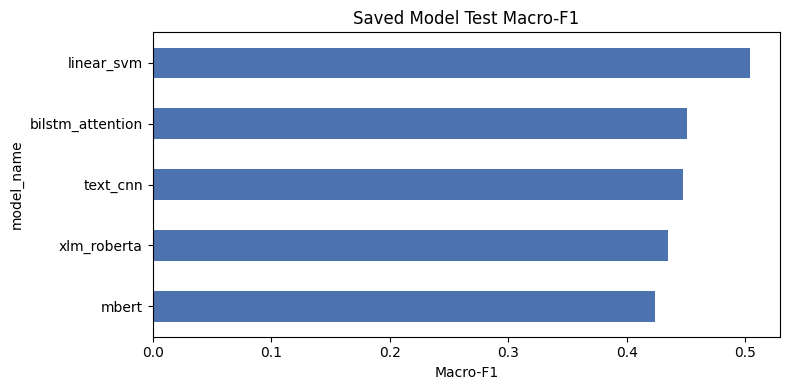

In [3]:
models = ['linear_svm', 'bilstm_attention', 'text_cnn', 'xlm_roberta', 'mbert']
selected = comparison[comparison['model_name'].isin(models)].sort_values('test_macro_f1', ascending=False)
display(selected[['model_family', 'model_name', 'test_accuracy', 'test_macro_f1', 'neutral_f1']].style.format('{:.4f}', subset=['test_accuracy', 'test_macro_f1', 'neutral_f1']))
selected.set_index('model_name')['test_macro_f1'].sort_values().plot(kind='barh', figsize=(8, 4), color='#4c72b0')
plt.title('Saved Model Test Macro-F1')
plt.xlabel('Macro-F1')
plt.tight_layout()
plt.show()

## Neutral Class Failure
Both transformer models have 0.0000 Neutral F1 in the final comparison. The tiny Neutral support and one-epoch limit prevented meaningful minority-class learning.

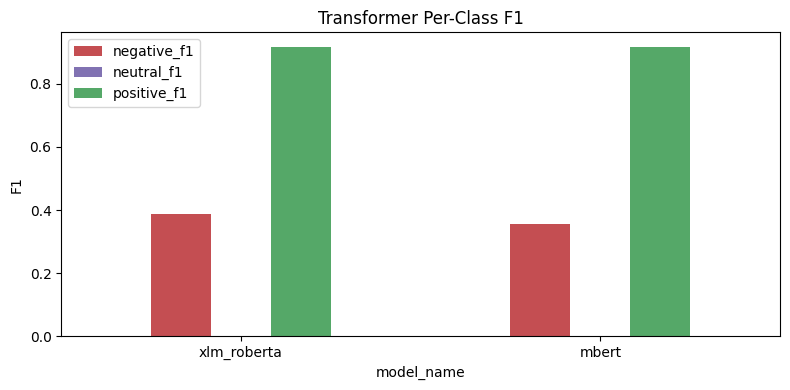

In [4]:
comparison.loc[comparison['model_family'].eq('transformer'), ['model_name', 'negative_f1', 'neutral_f1', 'positive_f1']].set_index('model_name').plot(kind='bar', figsize=(8, 4), color=['#c44e52', '#8172b2', '#55a868'])
plt.title('Transformer Per-Class F1')
plt.ylabel('F1')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Explanation Assistant
The assistant is rule-based and template-based, not a true LLM. It reports prediction metadata and simple text characteristics; it does not recover causal model reasoning.

In [5]:
samples = explanation_samples if isinstance(explanation_samples, list) else explanation_samples.get('samples', [])
pd.DataFrame(samples).head(8)

,text,true_label,predicted_label,confidence,is_correct,explanation
0,ٹیچر سال کے مہینوں کے نام بتاؤ سٹوڈنٹ جنوری فر...,Positive,Positive,0.874036,True,mbert predicted the sentiment as **Positive** ...
1,چلو کوئی نہی کنجوس,Positive,Positive,0.655661,True,mbert predicted the sentiment as **Positive** ...
2,کوئی تے روکو کھوتے نے سبکو پرچی پر لگا دیا,Positive,Positive,0.830534,True,mbert predicted the sentiment as **Positive** ...
3,ہونا چاہیے,Positive,Positive,0.783233,True,mbert predicted the sentiment as **Positive** ...
4,ضروری اس لئے تھا معذرت کا لفظ استعمال کرنا کیو...,Positive,Positive,0.884902,True,mbert predicted the sentiment as **Positive** ...
5,کرو میری پن ٹویٹ کو جلدی جلدی,Negative,Positive,0.876554,False,"Error Analysis: True label is **Negative**, bu..."
6,آپکا بڑا نقصان یہ بھی ھے کہ آپ سے کسی کا اعتما...,Negative,Positive,0.783711,False,"Error Analysis: True label is **Negative**, bu..."
7,تیز بارش میں کبھی سرد ہواؤں میں رہا اک ترا ذکر...,Positive,Negative,0.750793,False,"Error Analysis: True label is **Positive**, bu..."


## Key Takeaways
XLM-RoBERTa was the best transformer at 0.4346 test Macro-F1, but Linear SVM remained best overall at 0.5040. Transformer conclusions are limited by the 50,000-example, one-epoch setup.